In [ ]:
from common_config import *

In [1]:
import pandas as pd
classes = pd.read_pickle("./classes.pkl")
N_LAYERS =26

In [2]:
classes.keys()

dict_keys(['sarcastic_surfpos', 'paired_sincere_pos', 'sarcastic_surfneg', 'paired_sincere_neg', 'baseline_sincere_pos', 'baseline_sincere_neg'])

In [3]:
from huggingface_hub import login
import os
from dotenv import load_dotenv

load_dotenv()

if "HF_TOKEN" in os.environ:
    print("Success: HF_TOKEN loaded.")



Success: HF_TOKEN loaded.


In [5]:
# kill -9 <PID>

In [3]:
!nvidia-smi

Thu Jul  9 13:58:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.03             Driver Version: 580.159.03     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:C1:00.0 Off |                  N/A |
|  0%   36C    P8             28W /  250W |   22090MiB /  24576MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:

import torch
from transformer_lens import HookedTransformer
import numpy as np
import matplotlib.pyplot as plt

device = "cuda"
torch.cuda.empty_cache()
import gc
gc.collect()

In [ ]:

import torch
from transformer_lens import HookedTransformer
import numpy as np
import matplotlib.pyplot as plt

device = "cuda"
torch.cuda.empty_cache()
import gc
gc.collect()

model = HookedTransformer.from_pretrained("Gemma-2-9B", device=device)
model.eval()
N_LAYERS = model.cfg.n_layers


config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.20 GiB. GPU 0 has a total capacity of 23.56 GiB of which 1.73 GiB is free. Process 11329 has 21.56 GiB memory in use. Including non-PyTorch memory, this process has 256.00 MiB memory in use. Of the allocated memory 0 bytes is allocated by PyTorch, and 0 bytes is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# Phase 0a: Extract residual stream activations
def get_resid_acts(texts, batch_size=16):
    """Returns dict: layer -> tensor [n_texts, d_model] of last-token resid_post."""
    acts = {l: [] for l in range(N_LAYERS)}
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        tokens = model.to_tokens(batch)
        last_idx = (tokens != model.tokenizer.pad_token_id).sum(dim=1) - 1
        with torch.no_grad():
            _, cache = model.run_with_cache(
                tokens,
                names_filter=lambda n: n.endswith("hook_resid_post")
            )
        for l in range(N_LAYERS):
            resid = cache[f"blocks.{l}.hook_resid_post"]
            acts[l].append(resid[torch.arange(len(batch)), last_idx].cpu())
        del cache
    return {l: torch.cat(v) for l, v in acts.items()}

In [4]:

# Phase 0b: Build sentiment direction
pos_texts = classes["baseline_sincere_pos"][:300]  # use 300 for speed
neg_texts = classes["baseline_sincere_neg"][:300]


In [11]:

# pos_acts = get_resid_acts(pos_texts)
# print("done")
# neg_acts = get_resid_acts(neg_texts)
# print("done")

pos_acts = pd.read_pickle("./artifacts-2B/pos_acts.pkl")
neg_acts = pd.read_pickle("./artifacts-2B/neg_acts.pkl")


In [12]:

sentiment_dir = {}
for l in range(N_LAYERS):
    d = pos_acts[l].mean(0) - neg_acts[l].mean(0)
    sentiment_dir[l] = d / d.norm()


In [13]:

# Phase 0c: Sanity check - held-out test set
pos_test = get_resid_acts(classes["paired_sincere_pos"])
neg_test = get_resid_acts(classes["paired_sincere_neg"])


paired_sentiment_dir = {}
for l in range(N_LAYERS):
    d = pos_test[l].mean(0) - neg_test[l].mean(0)
    paired_sentiment_dir[l] = d / d.norm()



In [14]:
cos_sims = {}
for l in range(N_LAYERS):
    a = paired_sentiment_dir[l]
    b = sentiment_dir[l]
    cos_sims = {l: (paired_sentiment_dir[l] @ sentiment_dir[l]).item() for l in range(N_LAYERS)}

for l, sim in cos_sims.items():
    print(f"layer {l:2d}: cos_sim = {sim:.3f}")


layer  0: cos_sim = 0.027
layer  1: cos_sim = 0.038
layer  2: cos_sim = 0.045
layer  3: cos_sim = 0.015
layer  4: cos_sim = 0.047
layer  5: cos_sim = 0.091
layer  6: cos_sim = 0.061
layer  7: cos_sim = 0.165
layer  8: cos_sim = 0.120
layer  9: cos_sim = 0.114
layer 10: cos_sim = 0.094
layer 11: cos_sim = 0.048
layer 12: cos_sim = 0.062
layer 13: cos_sim = 0.086
layer 14: cos_sim = 0.111
layer 15: cos_sim = 0.076
layer 16: cos_sim = 0.170
layer 17: cos_sim = 0.191
layer 18: cos_sim = 0.203
layer 19: cos_sim = 0.195
layer 20: cos_sim = 0.204
layer 21: cos_sim = 0.206
layer 22: cos_sim = 0.210
layer 23: cos_sim = 0.202
layer 24: cos_sim = 0.147
layer 25: cos_sim = 0.100


In [15]:

# Check separation at each layer
separations = []
for l in range(N_LAYERS):
    p = pos_test[l] @ sentiment_dir[l]   # projections
    n = neg_test[l] @ sentiment_dir[l]
    gap = (p.mean() - n.mean()) / torch.cat([p, n]).std()
    separations.append(gap.item())


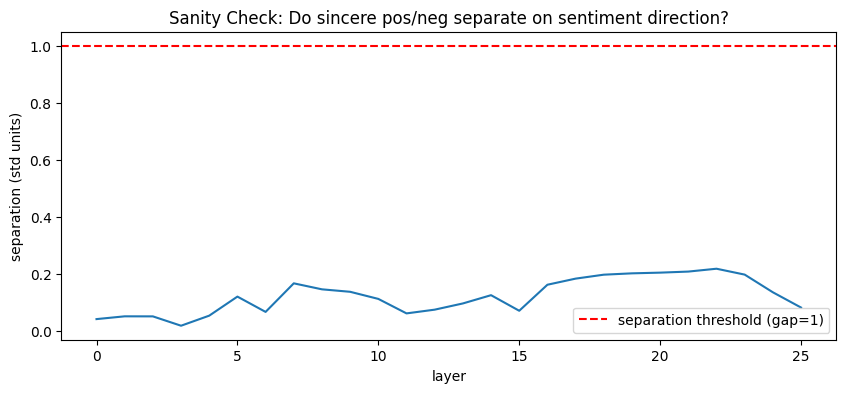

Separation by layer:
  layer 5: 0.12
  layer 10: 0.11
  layer 15: 0.07
  layer 20: 0.20
  layer 25: 0.08

 KILL SWITCH: Sentiment direction doesn't separate sincere texts. Pipeline broken.
Debug: check tokenization, padding, layer choice, or data quality.


In [16]:

# Plot it
plt.figure(figsize=(10, 4))
plt.plot(separations)
plt.axhline(1, color='r', linestyle='--', label='separation threshold (gap=1)')
plt.xlabel("layer")
plt.ylabel("separation (std units)")
plt.title("Sanity Check: Do sincere pos/neg separate on sentiment direction?")
plt.legend()
plt.savefig("sanity_check.png")
plt.show()

# Print key layers
print("Separation by layer:")
for l in [5, 10, 15, 20, 25]:
    print(f"  layer {l}: {separations[l]:.2f}")

# Kill switch
if max(separations[5:25]) < 1.0:
    print("\n KILL SWITCH: Sentiment direction doesn't separate sincere texts. Pipeline broken.")
    print("Debug: check tokenization, padding, layer choice, or data quality.")
else:
    print(f"\n✓ PASS: Best separation {max(separations[5:25]):.2f} at layer {np.argmax(separations[5:25]) + 5}")


In [ ]:
# import pickle
# from pathlib import Path

# OUT_DIR = Path("artifacts")
# OUT_DIR.mkdir(exist_ok=True)

# # Directions — small, always worth saving
# with open(OUT_DIR / "sentiment_dir.pkl", "wb") as f:
#     pickle.dump(sentiment_dir, f)

# # Activations — optional but cheap insurance against recompute
# with open(OUT_DIR / "pos_acts.pkl", "wb") as f:
#     pickle.dump(pos_acts, f)
# with open(OUT_DIR / "neg_acts.pkl", "wb") as f:
#     pickle.dump(neg_acts, f)

In [ ]:
import gc
del pos_acts, neg_acts  # explicitly delete big vars you don't need anymore
gc.collect()
torch.cuda.empty_cache()
del model
